Grid: ny=45, nx=22, total=990
Step: dlat=0.004492 deg, dlon=0.009038 deg
Start: (i=11, j=9) lat/lon=(60.142670, 21.503935)
Goal : (i=11, j=33) lat/lon=(60.250467, 21.503935)
Computing heatmap for wind-from 0° ...
Computing heatmap for wind-from 50° ...
Computing heatmap for wind-from 90° ...
Computing heatmap for wind-from 120° ...
Computing heatmap for wind-from 140° ...
Computing heatmap for wind-from 180° ...


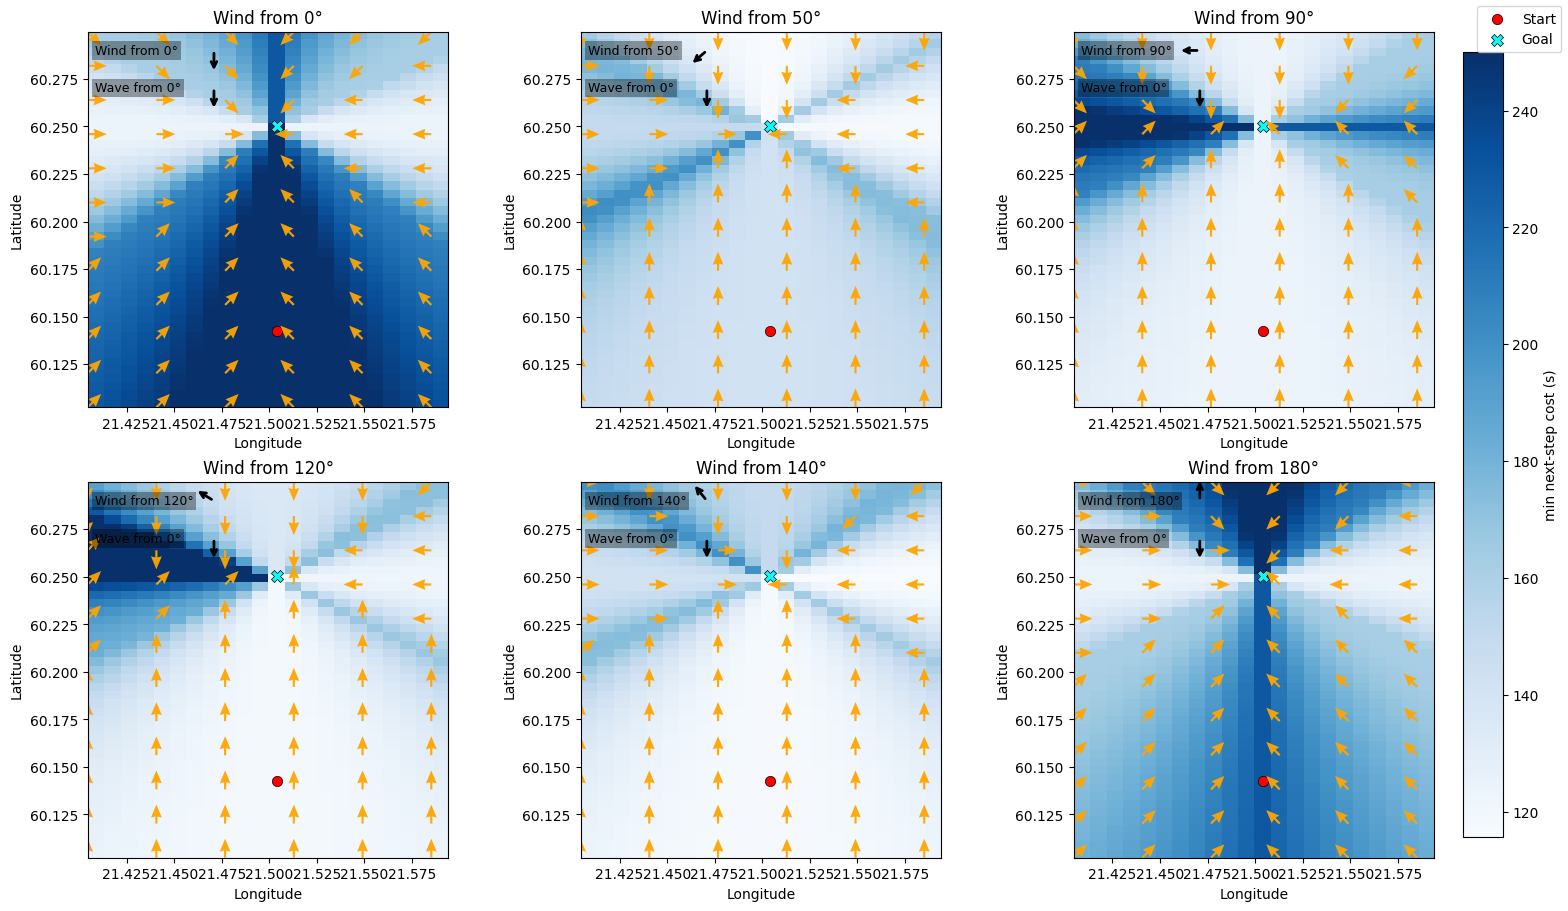

In [2]:
# =========================================================
# Heatmap series for multiple wind directions (wind coming FROM)
# + Start/Goal highlighted
# + Wind/Wave arrows show FLOW direction (away from source)
# + QUIVER overlay: lowest-cost heading per cell (downsampled)
#
# - Best-direction quivers are ORANGE
# =========================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

KNOT_TO_MS = 0.51444
g = 9.81

def to_numeric_array(arr):
    return pd.to_numeric(arr, errors="coerce").to_numpy(dtype=float)

def relative_angle(a, b):
    angle = abs(a - b) % 360
    return angle if angle <= 180 else 360 - angle

def angle_diff_180(a, b):
    return (a - b + 180) % 360 - 180

def twa_upwind_from_wind_from_and_heading(wind_from_deg, heading_deg):
    wind_to = (wind_from_deg + 180) % 360
    downwind_angle = abs(angle_diff_180(heading_deg, wind_to))
    return 180.0 - downwind_angle

def initial_bearing_deg(lat1, lon1, lat2, lon2):
    φ1, λ1 = np.deg2rad(lat1), np.deg2rad(lon1)
    φ2, λ2 = np.deg2rad(lat2), np.deg2rad(lon2)
    dλ = λ2 - λ1
    x = np.sin(dλ) * np.cos(φ2)
    y = np.cos(φ1) * np.sin(φ2) - np.sin(φ1) * np.cos(φ2) * np.cos(dλ)
    θ = np.arctan2(x, y)
    return (np.rad2deg(θ) + 360) % 360

def add_direction_arrow(ax, direction_deg, label, color="white",
                        anchor=(0.35, 0.95), length=0.06,
                        text_anchor=(0.2, 0.95),
                        text_deg=None):
    x0, y0 = anchor
    u = np.sin(np.deg2rad(direction_deg))
    v = np.cos(np.deg2rad(direction_deg))
    x1 = x0 + length * u
    y1 = y0 + length * v
    ax.annotate(
        "", xy=(x1, y1), xytext=(x0, y0),
        xycoords="axes fraction", textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color=color, lw=2)
    )
    if text_deg is None:
        text_deg = direction_deg
    xt, yt = text_anchor
    ax.text(
        xt, yt, f"{label} {text_deg:.0f}°",
        transform=ax.transAxes, color=color, fontsize=9,
        ha="left", va="center",
        bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=2)
    )

def load_polar_data(polar_csv, rb_csv):
    df = pd.read_csv(polar_csv, header=None, dtype=str, skip_blank_lines=False)
    TWS_knots = to_numeric_array(df.iloc[0, 2:])
    TWS_ms = TWS_knots * KNOT_TO_MS
    TWA = to_numeric_array(df.iloc[4:15, 1])
    Vs_table = (
        df.iloc[4:15, 2:2 + len(TWS_ms)]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float) * KNOT_TO_MS
    )
    interp_polar = RegularGridInterpolator((TWA, TWS_ms), Vs_table, bounds_error=False, fill_value=None)

    df_rb = pd.read_csv(rb_csv, header=None, dtype=str, skip_blank_lines=False)
    df_rb_num = df_rb.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")

    TWS_rb_knots = to_numeric_array(df_rb.iloc[1, 2:])
    TWS_rb = TWS_rb_knots * KNOT_TO_MS

    beating_TWA, beating_Vs = [], []
    running_TWA, running_Vs = [], []

    for i, row in enumerate(df_rb.itertuples(index=False)):
        label = str(row[0])
        TWA_val = df_rb_num.iloc[i, 0]
        if np.isnan(TWA_val):
            continue
        values = df_rb_num.iloc[i, 1:].to_numpy(dtype=float)
        valid_idx = np.where(~np.isnan(values))[0]
        if len(valid_idx) == 0:
            continue
        j = valid_idx[0]
        tws = TWS_rb[j]
        Vs_val = values[j] * KNOT_TO_MS
        if "Beating" in label:
            beating_TWA.append((tws, TWA_val))
            beating_Vs.append((tws, Vs_val))
        elif "Running" in label:
            running_TWA.append((tws, TWA_val))
            running_Vs.append((tws, Vs_val))

    return {
        "TWS": TWS_ms,
        "TWA": TWA,
        "interp_polar": interp_polar,
        "beating_TWA": np.array(beating_TWA),
        "beating_Vs": np.array(beating_Vs),
        "running_TWA": np.array(running_TWA),
        "running_Vs": np.array(running_Vs),
    }

def compute_Vs(TWA_input, TWS_input, data):
    TWS = data["TWS"]
    interp_polar = data["interp_polar"]
    beating_TWA = data["beating_TWA"]
    running_TWA = data["running_TWA"]
    if TWS_input < TWS[0] or TWS_input > TWS[-1]:
        return 0.0
    TWA_beat = np.interp(TWS_input, beating_TWA[:, 0], beating_TWA[:, 1])
    TWA_run = np.interp(TWS_input, running_TWA[:, 0], running_TWA[:, 1])
    if TWA_input < TWA_beat or TWA_input > TWA_run:
        return 0.0
    return float(interp_polar((TWA_input, TWS_input)))

def sailboat_speed_single_cell(TWA, TWS, Hs, T, wave_dir, depth, draft, compute_Vs, data, boat_heading):
    if depth < draft:
        return np.nan, {"valid_depth": False}
    V_polar = compute_Vs(TWA, TWS, data)
    if T is None or np.isnan(T) or T <= 0:
        return np.nan, {"valid_wave": False, "V_polar": V_polar}
    delta_theta = relative_angle(wave_dir, boat_heading)
    V_ship = max(V_polar, 0.1)
    omega = 2 * np.pi / T
    omega_e = omega * (1 - (V_ship / (g * T)) * math.cos(math.radians(delta_theta)))
    T_enc = 2 * np.pi / max(abs(omega_e), 1e-6)
    S = (2 * np.pi * Hs) / (g * T_enc**2)
    P_wave = 1.0 / (1.0 + S**2)
    V_eff = V_polar * P_wave
    return V_eff, {"V_polar": V_polar, "delta_theta": delta_theta, "T_enc": T_enc, "S": S, "P_wave": P_wave}

CELL_SIZE_M = 500.0
SQRT2 = np.sqrt(2)
HEADINGS_8 = np.array([0, 45, 90, 135, 180, 225, 270, 315])

def compute_vmg(V_eff, heading, goal_dir):
    angle = np.radians(heading - goal_dir)
    return V_eff * np.cos(angle)

def cell_distance(heading):
    return CELL_SIZE_M if heading % 90 == 0 else CELL_SIZE_M * SQRT2

def compute_vmg_cost_surface_cell(wind_from_dir, TWS, Hs, T, wave_dir, depth, draft, compute_Vs, data, goal_dir):
    costs = np.full(len(HEADINGS_8), np.inf, dtype=float)
    for i, hdg in enumerate(HEADINGS_8):
        TWA = twa_upwind_from_wind_from_and_heading(wind_from_dir, hdg)
        V_eff, _diag = sailboat_speed_single_cell(
            TWA=TWA, TWS=TWS, Hs=Hs, T=T, wave_dir=wave_dir, depth=depth, draft=draft,
            compute_Vs=compute_Vs, data=data, boat_heading=hdg
        )
        if np.isnan(V_eff) or V_eff <= 0:
            continue
        vmg = compute_vmg(V_eff, hdg, goal_dir)
        if vmg <= 0:
            continue
        costs[i] = cell_distance(hdg) / vmg
    return costs

def make_latlon_grid(lat_min, lat_max, lon_min, lon_max, cell_m=500.0):
    m_per_deg_lat = 111_320.0
    lat0 = 0.5 * (lat_min + lat_max)
    m_per_deg_lon = 111_320.0 * np.cos(np.deg2rad(lat0))
    dlat = cell_m / m_per_deg_lat
    dlon = cell_m / m_per_deg_lon
    lats = np.arange(lat_min + 0.5 * dlat, lat_max, dlat)
    lons = np.arange(lon_min + 0.5 * dlon, lon_max, dlon)
    return lats, lons, dlat, dlon

def random_start_goal(lats, lons, rng=None, land_mask=None, min_sep_cells=0, edge_margin_cells=0):
    rng = np.random.default_rng(rng)
    ny, nx = len(lats), len(lons)
    j0 = edge_margin_cells
    j1 = ny - edge_margin_cells
    i0 = edge_margin_cells
    i1 = nx - edge_margin_cells
    if j1 <= j0 or i1 <= i0:
        raise ValueError("edge_margin_cells too large for this grid.")

    def is_ok(j, i):
        if land_mask is None:
            return True
        return not land_mask[j, i]

    while True:
        sj = rng.integers(j0, j1)
        si = rng.integers(i0, i1)
        if is_ok(sj, si):
            break

    while True:
        gj = rng.integers(j0, j1)
        gi = rng.integers(i0, i1)
        if (gj == sj and gi == si):
            continue
        if not is_ok(gj, gi):
            continue
        if min_sep_cells > 0 and (abs(gj - sj) + abs(gi - si) < min_sep_cells):
            continue
        break

    return (si, sj), (gi, gj)

def compute_min_cost_map(lats, lons, goal_lat, goal_lon,
                         wind_from_dir, TWS, Hs, T, wave_dir,
                         depth, draft, compute_Vs, data, land_mask=None):
    ny, nx = len(lats), len(lons)
    min_cost_map = np.full((ny, nx), np.nan, dtype=float)
    best_hdg_map = np.full((ny, nx), np.nan, dtype=float)

    if depth < draft:
        return min_cost_map, best_hdg_map

    for j in range(ny):
        for i in range(nx):
            if land_mask is not None and land_mask[j, i]:
                continue
            goal_dir = initial_bearing_deg(lats[j], lons[i], goal_lat, goal_lon)
            costs = compute_vmg_cost_surface_cell(
                wind_from_dir=wind_from_dir, TWS=TWS, Hs=Hs, T=T, wave_dir=wave_dir,
                depth=depth, draft=draft, compute_Vs=compute_Vs, data=data, goal_dir=goal_dir
            )
            k = int(np.argmin(costs))
            if np.isfinite(costs[k]):
                min_cost_map[j, i] = costs[k]
                best_hdg_map[j, i] = HEADINGS_8[k]

    return min_cost_map, best_hdg_map

def plot_heatmap_series(maps, best_hdgs, wind_dirs,
                        lats, lons, start_lat, start_lon, goal_lat, goal_lon,
                        wave_dir_from, cmap="viridis_r", vmax_percentile=95,
                        quiver_step=4):
    extent = [lons[0], lons[-1], lats[0], lats[-1]]

    finite_vals = []
    for m in maps:
        v = m[np.isfinite(m)]
        if v.size:
            finite_vals.append(v.ravel())
    all_vals = np.concatenate(finite_vals) if finite_vals else np.array([0.0])

    vmin = float(np.nanmin(all_vals))
    vmax = float(np.nanpercentile(all_vals, vmax_percentile))

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    axes = axes.ravel()

    last_im = None
    for ax, m, bh, wd in zip(axes, maps, best_hdgs, wind_dirs):
        last_im = ax.imshow(m, origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)

        ax.scatter([start_lon], [start_lat], c="red", s=55, marker="o",
                   edgecolors="black", linewidths=0.5, label="Start")
        ax.scatter([goal_lon], [goal_lat], c="cyan", s=75, marker="X",
                   edgecolors="black", linewidths=0.5, label="Goal")

        wind_arrow_dir = (wd + 180) % 360
        wave_arrow_dir = (wave_dir_from + 180) % 360

        add_direction_arrow(ax, wind_arrow_dir, label="Wind from", color="black",
                            anchor=(0.35, 0.95), length=0.06,
                            text_anchor=(0.02, 0.95), text_deg=wd)
        add_direction_arrow(ax, wave_arrow_dir, label="Wave from", color="black",
                            anchor=(0.35, 0.85), length=0.06,
                            text_anchor=(0.02, 0.85), text_deg=wave_dir_from)
        ny, nx = m.shape
        jj = np.arange(0, ny, quiver_step)
        ii = np.arange(0, nx, quiver_step)
        Lon, Lat = np.meshgrid(lons[ii], lats[jj])

        hdg = bh[np.ix_(jj, ii)]
        ok = np.isfinite(hdg)

        U = np.sin(np.deg2rad(hdg))
        V = np.cos(np.deg2rad(hdg))

        ax.quiver(
            Lon[ok], Lat[ok], U[ok], V[ok],
            color="orange",
            angles="xy",
            scale_units="xy",
            scale=100,          # smaller => longer arrows
            width=0.006,       # thicker
            headwidth=5.0,
            headlength=6.0,
            headaxislength=5.5,
            alpha=0.95
        )

        ax.set_title(f"Wind from {wd}°")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    cbar = fig.colorbar(last_im, ax=axes, shrink=0.95, pad=0.02)
    cbar.set_label("min next-step cost (s)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.show()

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":

    data = load_polar_data(
        "inputs/polars_hallberg_rassy_342.csv",
        "inputs/beating_running.csv"
    )

    min_lon, max_lon = 21.4, 21.6
    min_lat, max_lat = 60.1, 60.3

    lats, lons, dlat, dlon = make_latlon_grid(min_lat, max_lat, min_lon, max_lon, cell_m=500.0)
    ny, nx = len(lats), len(lons)
    print(f"Grid: ny={ny}, nx={nx}, total={ny*nx:,}")
    print(f"Step: dlat={dlat:.6f} deg, dlon={dlon:.6f} deg")

    land_mask = None

    SEED = 200
    EDGE_MARGIN_CELLS = 8
    MIN_SEP_CELLS = 20

    (si, sj), (gi, gj) = random_start_goal(
        lats, lons,
        rng=SEED,
        land_mask=land_mask,
        min_sep_cells=MIN_SEP_CELLS,
        edge_margin_cells=EDGE_MARGIN_CELLS
    )

    start_lat, start_lon = lats[sj], lons[si]
    goal_lat, goal_lon = lats[gj], lons[gi]

    print(f"Start: (i={si}, j={sj}) lat/lon=({start_lat:.6f}, {start_lon:.6f})")
    print(f"Goal : (i={gi}, j={gj}) lat/lon=({goal_lat:.6f}, {goal_lon:.6f})")

    depth = 5.0
    draft = 2.0
    TWS_ms = 20.0 * KNOT_TO_MS

    wave_height = 0.5
    wave_period = 6.0

    wave_dir_from = 0
    wave_dir_for_model = wave_dir_from

    wind_dirs = [0, 50, 90, 120, 140, 180]

    maps = []
    best_hdgs = []
    for wd in wind_dirs:
        print(f"Computing heatmap for wind-from {wd}° ...")
        m, bh = compute_min_cost_map(
            lats=lats, lons=lons,
            goal_lat=goal_lat, goal_lon=goal_lon,
            wind_from_dir=float(wd),
            TWS=TWS_ms,
            Hs=wave_height,
            T=wave_period,
            wave_dir=wave_dir_for_model,
            depth=depth,
            draft=draft,
            compute_Vs=compute_Vs,
            data=data,
            land_mask=land_mask
        )
        maps.append(m)
        best_hdgs.append(bh)

    plot_heatmap_series(
        maps=maps,
        best_hdgs=best_hdgs,
        wind_dirs=wind_dirs,
        lats=lats, lons=lons,
        start_lat=start_lat, start_lon=start_lon,
        goal_lat=goal_lat, goal_lon=goal_lon,
        wave_dir_from=wave_dir_from,
        cmap="Blues",
        vmax_percentile=95,
        quiver_step=4   # smaller => more arrows
    )